<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/house_price_prediction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing dependence

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBRegressor


Import data set for house price

In [38]:
house_price_dataset = pd.read_csv('/content/sample_data/House Price Prediction Dataset.csv')

In [39]:
print(house_price_dataset)

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  
0    

In [40]:
house_price_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [41]:
# print first 5 line
house_price_dataset.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [42]:
# print last 5 line
house_price_dataset.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [43]:
# check number of roe and column in dataset
house_price_dataset.shape

(2000, 10)

In [44]:
#checking null value in data set
house_price_dataset.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [45]:
# statstical measure of dataset
house_price_dataset.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [46]:
#converting to numerical value
house_price_dataset.replace({"Location":{ 'Downtown': 0,'Suburban': 1,'Rural': 2,'Urban': 3},"Condition":{ 'Poor': 1, 'Fair': 2, 'Good': 3,'Excellent': 4},"Garage":{"Yes":1,"No":0}},inplace=True)


/tmp/ipython-input-2267394215.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  house_price_dataset.replace({"Location":{ 'Downtown': 0,'Suburban': 1,'Rural': 2,'Urban': 3},"Condition":{ 'Poor': 1, 'Fair': 2, 'Good': 3,'Excellent': 4},"Garage":{"Yes":1,"No":0}},inplace=True)


In [47]:
# print first 5 line
house_price_dataset.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,4,0,149919
1,2,4272,5,4,3,1958,0,4,0,424998
2,3,3592,2,2,3,1938,0,3,0,266746
3,4,966,4,2,2,1902,1,2,1,244020
4,5,4926,1,4,2,1975,0,2,1,636056


In [48]:
# print last 5 line
house_price_dataset.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,1,1,0,295620
1996,1997,3046,5,2,1,2019,1,1,1,580929
1997,1998,1062,5,1,2,1903,2,1,0,476925
1998,1999,4062,3,1,2,1936,3,4,1,161119
1999,2000,2989,5,1,3,1903,1,2,0,482525


various correlation between different feature in dataset

1.postive correlation
2.negative correlation

---



---



In [49]:
correlation=house_price_dataset.corr()

constructing heatmap to understand correlation

<Axes: >

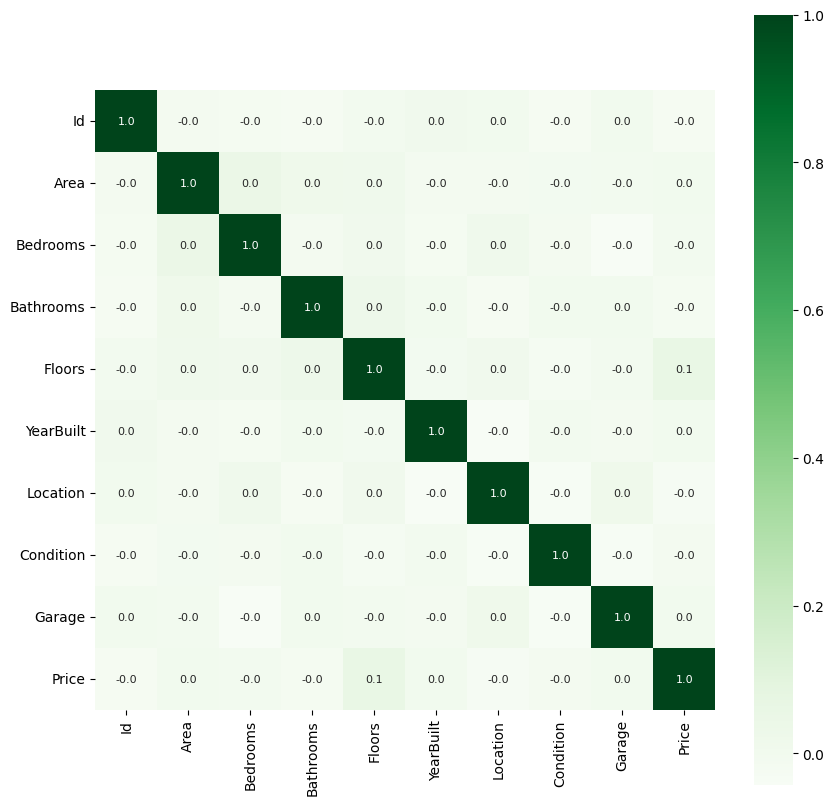

In [50]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Greens')

splitting the data and target

In [51]:
y=house_price_dataset['Price']
x=house_price_dataset.drop(['Price','Id'],axis=1)

In [17]:
print(x)
print(y)

      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0     1360         5          4       3       1970         0          4   
1     4272         5          4       3       1958         0          4   
2     3592         2          2       3       1938         0          3   
3      966         4          2       2       1902         1          2   
4     4926         1          4       2       1975         0          2   
...    ...       ...        ...     ...        ...       ...        ...   
1995  4994         5          4       3       1923         1          1   
1996  3046         5          2       1       2019         1          1   
1997  1062         5          1       2       1903         2          1   
1998  4062         3          1       2       1936         3          4   
1999  2989         5          1       3       1903         1          2   

      Garage  
0          0  
1          0  
2          0  
3          1  
4          1  
...      

spiliting data into test and train data

In [52]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=2)

In [53]:
print(x.shape,x_train.shape,x_test.shape)

(2000, 8) (1600, 8) (400, 8)


Model Training

XGBoost Regressor

In [54]:
#loading models
model=XGBRegressor()

In [55]:
#training mode x_train and y_train
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Model Evaluation


predicition in training data


In [56]:
#accuracy for prediction on training data
training_data_prediction=model.predict(x_train)

In [57]:
print(training_data_prediction)

[544039.44 906365.56 435116.47 ... 687776.56 533639.44 860591.4 ]


In [58]:
# R square error
score_1=metrics.r2_score(y_train,training_data_prediction)

In [59]:
# mean absolute error
score_2=metrics.mean_absolute_error(y_train,training_data_prediction)

In [60]:
print('R square error:',score_1)
print('Mean absolute error:',score_2)

R square error: 0.9449906349182129
Mean absolute error: 48725.19140625


Test data prediction

In [61]:
#accuracy for prediction on training data
test_data_prediction=model.predict(x_test)

In [62]:
print(test_data_prediction)

[620090.06 502864.47 693641.25 498710.1  625619.25 441102.5  522268.97
 662350.1  452358.   336268.88 516967.34 368339.4  710559.06 261261.33
 546895.5  372616.25 376115.75 805474.75 692870.25 658943.44 493069.5
 702862.25 582009.7  709907.44 483607.75 551951.1  832664.3  545444.44
 722506.5  760632.56 580498.6  581465.3  652917.75 511916.   667616.75
 487320.03 837038.7  604019.56 576141.9  536898.06 432555.97 580380.9
 667223.9  641444.44 529718.5  633459.5  582488.75 631495.1  561348.5
 654197.75 442729.6  480292.1  426813.75 573048.75 467702.66 354345.6
 804132.6  542451.2  633521.06 604402.9  659588.56 772126.06 660682.44
 641157.56 653193.8  659941.25 788400.4  678825.56 707506.9  453448.28
 609865.3  501426.1  587434.8  504427.66 610725.06 307895.84 391429.9
 539413.56 257381.89 559703.5  303652.53 631153.   454391.88 511156.9
 416174.97 516057.53 424660.   508222.4  701838.6  399530.1  262713.75
 549275.4  709546.3  462845.56 464949.2  311515.12 455404.97 826739.25
 334390.75 6

In [63]:
# R square error
score_1=metrics.r2_score(y_test,test_data_prediction)

In [64]:
# mean absolute error
score_2=metrics.mean_absolute_error(y_test,test_data_prediction)

In [65]:
print('R square error:',score_1)
print('Mean absolute error:',score_2)

R square error: -0.29299426078796387
Mean absolute error: 263743.71875


Prediction system

In [66]:
def input_data():
    print("Please enter detailed information for house price prediction:")

    house_info = {}

    # Capture the area of the house in square feet
    Area = float(input("Enter the total area of the house (in square feet): "))

    # Capture the number of bedrooms
    Bedrooms = int(input("Enter the number of bedrooms: "))

    # Capture the number of bathrooms
    Bathrooms = int(input("Enter the number of bathrooms: "))

    # Capture the number of floors
    Floors = int(input("Enter the number of floors: "))

    # Capture the year the house was built
    YearBuilt = int(input("Enter the year the house was built (e.g., 1990): "))

    # Capture the location of the house (city, neighborhood, etc.)
    Location = input("Enter the location of the house (city or neighborhood): ")

    # Capture the condition of the house
    Condition = input("Enter the condition of the house (new, good, needs renovation): ")

    # Capture the garage information
    Garage = input("Does the house have a garage? (yes/no or specify number of cars): ")

    # Append all the information to the house_info dictionary
    house_info = {
        "Area": Area,
        "Bedrooms": Bedrooms,
        "Bathrooms": Bathrooms,
        "Floors": Floors,
        "YearBuilt": YearBuilt,
        "Location": Location,
        "Condition": Condition,
        "Garage": Garage
    }

    return house_info;




In [67]:

def predict_house_price(input_data):
    # Convert input data to DataFrame
    data_for_prediction = pd.DataFrame(input_data, index=[0])

    # Replace categorical variables with numerical representations
    data_for_prediction.replace({
        "Location": {'Downtown': 0, 'Suburban': 1, 'Rural': 2, 'Urban': 3},
        "Condition": {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
        "Garage": {"Yes": 1, "No": 0}
    }, inplace=True)

    # Ensure the DataFrame has the same columns as the training set
    expected_columns = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']
    for col in expected_columns:
        if col not in data_for_prediction.columns:
            data_for_prediction[col] = 0  # or handle as per your requirements

    # Make the prediction
    prediction_data = model.predict(data_for_prediction)
    return prediction_data



In [68]:
# Example input data
# new_house_price = input_data()
new_house_price = input_data()

house_price = predict_house_price(new_house_price)
print('house price:', house_price)


Please enter detailed information for house price prediction:
Enter the total area of the house (in square feet): 180
Enter the number of bedrooms: 3
Enter the number of bathrooms: 2
Enter the number of floors: 3
Enter the year the house was built (e.g., 1990): 2002
Enter the location of the house (city or neighborhood): Downtown
Enter the condition of the house (new, good, needs renovation): Good
Does the house have a garage? (yes/no or specify number of cars): Yes
house price: [508851.25]


/tmp/ipython-input-3032137294.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_for_prediction.replace({
